# 손 X-ray 골연령 예측 — **Xception 회귀 / 전처리 = CLAHE + 512 리사이즈만**

> Zhang, Wu, Zhou & Li, *Uncertainty-aware multi-stream deep learning for pediatric bone age assessment* (JKSU-CIS, 2026)
> 최종모델 노트북의 **경로·환경·학습 레시피는 그대로**, **전처리만 최소화**한 대조군(control) 노트북입니다.

## 이 노트북이 이전 노트북과 다른 점

| 항목 | 이전(최종파이프라인) | **이 노트북** |
|---|---|---|
| 손 크롭 | `paper` / `plate` / `advanced` 3종 | **없음 (원본 전체 사용)** |
| 마커·프레임 소거 | advanced 모드에서 수행 | **없음** |
| 밝기 정합 | advanced 모드에서 수행 | **없음** |
| 히스토그램 처리 | `he` / `clahe` / `none` 선택 | **CLAHE 고정 (원본 해상도에서 1회)** |
| 리사이즈 | 크롭 후 정사각 512 | **원본 → 정사각 512 (그대로 눌러 담기)** |
| 이상 이미지 제외 | `EXCLUDE_IDS` 15장 제외 | **기본 미적용** (`USE_EXCLUDE_IDS` 토글) |
| 모델·학습·평가 | Xception 회귀 헤드 | **동일** |

즉 전처리 파이프라인의 **하한선(lower bound)** 을 측정하는 실험입니다.
이 결과와 크롭·마커소거 버전을 비교하면 "전처리가 MAE를 몇 개월 줄였는가"를 정량화할 수 있습니다.

## 전처리 (딱 3줄)

```
① 흑백 로드  →  ② CLAHE (원본 해상도)  →  ③ cv2.resize(512, 512)
```

## 모델 (논문 §3.4 식 13~17)
$$\mathbf{z}=\mathrm{Flat}\big(\mathrm{MaxPool}_{3\times3}(\mathrm{Conv}_{3\times3}(\mathbf{F}))\big),\qquad
\mathbf{e}=\phi_\psi(g)\in\mathbb{R}^{32},\qquad
\hat{y}=\mathbf{w}^\top[\mathbf{z};\mathbf{e}]+b$$

- Bilinear pooling 없음 · Xception 백본(timm `legacy_xception`)
- 캐시/체크포인트 폴더가 이전 노트북과 **완전히 분리**되어 있어 기존 실험을 덮어쓰지 않습니다.

## 실행 순서
`PART 0` (전부) → `PART 1` (전처리 캐시 1회) → `PART 2` → `PART 3` (학습) → `PART 4` (평가)


---
# PART 0 · 공통 셋업  *(항상 먼저 실행 — 전부 정의/로드, 무거운 연산 없음)*

### 0-1. 환경 확인

In [1]:
import os, sys, json, math, random, time
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms
from tqdm.auto import tqdm

# Xception은 torchvision에 없습니다 -> timm 필요 (최초 1회만 설치)
# !pip install timm
import timm

print("Python     :", sys.version.split()[0])
print("PyTorch    :", torch.__version__)
print("torchvision:", torchvision.__version__)
print("timm       :", timm.__version__)
print("OpenCV     :", cv2.__version__)
print("CUDA avail :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU        :", torch.cuda.get_device_name(0), "| CUDA", torch.version.cuda)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device     :", device)

# [주의] RTX 5060(Blackwell, sm_120)은 최신 PyTorch 필요.
# CUDA=False 이거나 'no kernel image' 오류 시 CUDA 12.8+ 빌드 설치:
#   pip install --pre torch torchvision --index-url https://download.pytorch.org/whl/nightly/cu128

Python     : 3.11.9
PyTorch    : 2.12.0.dev20260408+cu128
torchvision: 0.27.0.dev20260407+cu128
timm       : 1.0.28
OpenCV     : 4.10.0
CUDA avail : True
GPU        : NVIDIA GeForce RTX 5060 Laptop GPU | CUDA 12.8
device     : cuda


### 0-2. 시드 & 한글 경로 로더
`cv2.imread/imwrite`는 경로에 한글이 있으면 **조용히 실패**합니다 → `np.fromfile + imdecode` 조합을 씁니다.

In [2]:
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

def imread_kr(path, flags=cv2.IMREAD_GRAYSCALE):
    '''한글/유니코드 경로에서도 동작하는 이미지 로드. 실패 시 None.'''
    try:
        data = np.fromfile(str(path), dtype=np.uint8)
        return cv2.imdecode(data, flags)
    except Exception:
        return None

def imwrite_kr(path, img):
    '''한글/유니코드 경로에도 저장 가능한 이미지 쓰기.'''
    path = str(path); ext = os.path.splitext(path)[1] or ".png"
    ok, buf = cv2.imencode(ext, img)
    if ok: buf.tofile(path)
    return ok

def torch_load(path, map_location=None):
    '''PyTorch 2.6+ 는 weights_only 기본값이 True -> arch 딕셔너리 로드가 막힙니다.'''
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:                       # 구버전 PyTorch 호환
        return torch.load(path, map_location=map_location)

print("시드 고정 완료 · 한글 경로 로더 준비 완료")

시드 고정 완료 · 한글 경로 로더 준비 완료


### 0-3. 경로 설정 & 전처리 파라미터
**`BASE_DIR` 한 줄만** 본인 경로로 수정하세요. 캐시·체크포인트 폴더는 이전 노트북과 **분리**되어 있습니다.

In [3]:
# ── 경로: 여기만 수정 ───────────────────────────────────────────────
BASE_DIR = Path(r"C:\Users\Win11Pro\Desktop\뼈데이터\전처리")   # ← 수정
CSV_DIR = Path(r"C:\Users\Win11Pro\Desktop\뼈데이터")

TRAIN_IMG_DIR = BASE_DIR / "train"
TRAIN_CSV     = CSV_DIR / "Bone+Age+Training+Set+Annotations" / "train.csv"
VAL_IMG_DIR   = BASE_DIR / "validation"
VAL_CSV       = CSV_DIR / "Bone+Age+Validation+Set" / "Bone Age Validation Set" / "Validation Dataset.csv"

# ── test 세트 (★ 실제 폴더/CSV 이름에 맞게 수정) ──────────────────────
TEST_IMG_DIR  = BASE_DIR / "test"
TEST_CSV      = CSV_DIR / "Bone+Age+Test+Set" / "Bone age ground truth.csv"

# ══ 전처리 설정 — 이 노트북의 핵심 ═══════════════════════════════════
IMG_SIZE     = 512        # 정사각 리사이즈 목표 크기
CLAHE_CLIP   = 2.0        # CLAHE clipLimit     (대비 증폭 상한, 클수록 강함)
CLAHE_TILE   = 8          # CLAHE tileGridSize  (8 -> 8x8 타일)
CLAHE_FIRST  = True       # True : 원본 해상도에서 CLAHE -> 리사이즈  (요청 사양)
                          # False: 리사이즈 -> CLAHE        (연산 가벼움, 비교실험용)
RESIZE_MODE  = "square"   # "square" : 종횡비 무시하고 512x512로 늘림 (이전 노트북과 동일)
                          # "pad"    : 종횡비 유지 + 검은 여백(letterbox)
USE_AUG      = False      # 논문 미언급. 재현 기준선은 False
# ══════════════════════════════════════════════════════════════════

# ── 이상 이미지 제외 스위치 ────────────────────────────────────────
# 이 노트북은 "전처리 없는 순수 베이스라인"이 목적이라 기본 False(전량 사용).
# 이전 노트북과 동일 조건으로 맞춰 비교하려면 True 로 바꾸세요.
USE_EXCLUDE_IDS = False
EXCLUDE_IDS = {""}

# 캐시/체크포인트: 이전 실험과 절대 섞이지 않도록 별도 폴더
PRE_TAG   = f"claheonly_{IMG_SIZE}_c{CLAHE_CLIP}_t{CLAHE_TILE}_{RESIZE_MODE}" + ("_pre" if CLAHE_FIRST else "_post")
CACHE_DIR = BASE_DIR / "cache_clahe_only" / PRE_TAG
CKPT_DIR  = BASE_DIR / "checkpoints_xception_clahe_only"
for d in (CACHE_DIR, CACHE_DIR/"train", CACHE_DIR/"val", CACHE_DIR/"test", CKPT_DIR):
    d.mkdir(parents=True, exist_ok=True)

BEST_CKPT    = CKPT_DIR / "best.pt"          # 배포/추론용(가벼움, 자체완결)
LAST_CKPT    = CKPT_DIR / "last.pt"          # 재개용(옵티마이저 포함)
HISTORY_JSON = CKPT_DIR / "history.json"
DONE_MARKER  = CACHE_DIR / "_DONE.json"

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

print(f"BASE_DIR : {BASE_DIR}")
print(f"전처리   : CLAHE(clip={CLAHE_CLIP}, tile={CLAHE_TILE}x{CLAHE_TILE}) "
      f"{'-> resize' if CLAHE_FIRST else '<- resize 뒤'} · {RESIZE_MODE} {IMG_SIZE}px · 크롭 없음")
print(f"제외목록 : {'적용' if USE_EXCLUDE_IDS else '미적용(전량 사용)'}")
print(f"CACHE    : {CACHE_DIR}")
print(f"CKPT     : {CKPT_DIR}")

BASE_DIR : C:\Users\Win11Pro\Desktop\뼈데이터\전처리
전처리   : CLAHE(clip=2.0, tile=8x8) -> resize · square 512px · 크롭 없음
제외목록 : 미적용(전량 사용)
CACHE    : C:\Users\Win11Pro\Desktop\뼈데이터\전처리\cache_clahe_only\claheonly_512_c2.0_t8_square_pre
CKPT     : C:\Users\Win11Pro\Desktop\뼈데이터\전처리\checkpoints_xception_clahe_only


### 0-4. 라벨 로드 (CSV) & 타깃 통계

In [4]:
def load_labels(csv_path, img_dir):
    '''id/boneage/male 컬럼을 유연하게 탐지해 표준 DataFrame으로 반환.'''
    df = pd.read_csv(csv_path)
    cols = {c.lower().strip(): c for c in df.columns}
    def pick(keys):
        for k in keys:
            for lc, orig in cols.items():
                if k in lc: return orig
        return None
    id_col  = pick(["id", "case", "image"]) or df.columns[0]
    age_col = pick(["boneage", "bone age", "age"])
    sex_col = pick(["male", "sex", "gender"])
    assert age_col and sex_col, f"컬럼 탐지 실패: {list(df.columns)}"
    out = pd.DataFrame()
    out["id"]      = df[id_col].astype(str).str.replace(".png","",regex=False).str.strip()
    out["boneage"] = pd.to_numeric(df[age_col], errors="coerce")
    s = df[sex_col]
    if s.dtype == bool:
        male = s.astype(int)
    else:
        sv = s.astype(str).str.lower().str.strip()
        male = sv.map({"true":1,"false":0,"m":1,"f":0,"male":1,"female":0,"1":1,"0":0})
        if male.isna().any(): male = pd.to_numeric(s, errors="coerce")
    out["male"] = male.astype(float)
    out["path"] = out["id"].apply(lambda i: str(Path(img_dir)/f"{i}.png"))
    return out.dropna(subset=["boneage","male"]).reset_index(drop=True)

train_df = load_labels(TRAIN_CSV, TRAIN_IMG_DIR)
val_df   = load_labels(VAL_CSV,   VAL_IMG_DIR)

# test 세트 로드 (경로가 있으면). 없으면 빈 DF로 두고 안내만.
HAS_TEST = TEST_CSV.exists() and TEST_IMG_DIR.exists()
if HAS_TEST:
    test_df = load_labels(TEST_CSV, TEST_IMG_DIR)
else:
    test_df = pd.DataFrame(columns=["id","boneage","male","path"])
    print("⚠ test 세트를 찾지 못했습니다 → 셀 0-3의 TEST_IMG_DIR / TEST_CSV 경로를 확인하세요.")
    print("   IMG:", TEST_IMG_DIR); print("   CSV:", TEST_CSV)

# ── 이상 이미지 제외 (스위치가 켜져 있을 때만) ──
def drop_excluded(df, name):
    if not USE_EXCLUDE_IDS or not len(df): return df
    before = len(df)
    df = df[~df["id"].isin(EXCLUDE_IDS)].reset_index(drop=True)
    if before - len(df):
        print(f"  · {name}: 이상 이미지 {before-len(df)}장 제외")
    return df
train_df = drop_excluded(train_df, "train")
val_df   = drop_excluded(val_df,   "val")
test_df  = drop_excluded(test_df,  "test")

AGE_MEAN = float(train_df.boneage.mean())     # 회귀 안정화용(가정): 학습셋 통계
AGE_STD  = float(train_df.boneage.std())
print(f"학습 {len(train_df):,} · 검증 {len(val_df):,} · 테스트 {len(test_df):,} "
      f"| 나이 {AGE_MEAN:.2f}±{AGE_STD:.2f} | 남 {train_df.male.mean():.1%}")

학습 12,611 · 검증 1,425 · 테스트 200 | 나이 127.32±41.18 | 남 54.2%


### 0-5. 전처리 함수 — **CLAHE + 리사이즈, 그게 전부**

| 단계 | 내용 | 비고 |
|---|---|---|
| ① 로드 | `IMREAD_GRAYSCALE` | 8bit 아니면 min-max로 8bit 환산 |
| ② CLAHE | `cv2.createCLAHE(clipLimit, tileGridSize)` | 원본 해상도에서 수행(`CLAHE_FIRST=True`) |
| ③ 리사이즈 | `square`(늘리기) 또는 `pad`(레터박스) | 축소는 `INTER_AREA`, 확대는 `INTER_CUBIC` |

> **크롭·마커소거·밝기정합·뼈마스크 전부 없음.** 이 노트북의 존재 이유가 "그것들이 없을 때 얼마나 나쁜가"를 재는 것이기 때문입니다.

In [5]:
def _to_uint8(g):
    '''16bit·float 입력도 안전하게 8bit로.'''
    if g.dtype == np.uint8:
        return g
    g = g.astype(np.float32)
    lo, hi = float(g.min()), float(g.max())
    if hi - lo < 1e-6:
        return np.zeros(g.shape, np.uint8)
    return np.clip((g - lo) / (hi - lo) * 255.0, 0, 255).astype(np.uint8)


def apply_clahe(g, clip=None, tile=None):
    '''대비제한 적응 히스토그램 평활화 (전역 equalizeHist와 달리 국소 대비를 살림).'''
    clip = CLAHE_CLIP if clip is None else clip
    tile = CLAHE_TILE if tile is None else tile
    clahe = cv2.createCLAHE(clipLimit=float(clip), tileGridSize=(int(tile), int(tile)))
    return clahe.apply(_to_uint8(g))


def resize_to(g, size, mode="square"):
    '''size x size 로 통일. square=종횡비 무시 / pad=종횡비 유지 + 검은 여백.'''
    h, w = g.shape[:2]
    if mode == "pad":
        s = size / max(h, w)
        nh, nw = max(1, int(round(h * s))), max(1, int(round(w * s)))
        interp = cv2.INTER_AREA if s < 1 else cv2.INTER_CUBIC
        r = cv2.resize(g, (nw, nh), interpolation=interp)
        out = np.zeros((size, size), np.uint8)
        y0, x0 = (size - nh) // 2, (size - nw) // 2
        out[y0:y0+nh, x0:x0+nw] = r
        return out
    interp = cv2.INTER_AREA if (h > size or w > size) else cv2.INTER_CUBIC
    return cv2.resize(g, (size, size), interpolation=interp)


def preprocess(gray, size=None, clip=None, tile=None, mode=None, clahe_first=None):
    '''① 8bit 변환 → ② CLAHE → ③ 정사각 리사이즈.  (크롭 없음)'''
    size        = IMG_SIZE     if size        is None else size
    mode        = RESIZE_MODE  if mode        is None else mode
    clahe_first = CLAHE_FIRST  if clahe_first is None else clahe_first

    g = _to_uint8(gray)
    if clahe_first:
        g = apply_clahe(g, clip, tile)      # 원본 해상도에서 평활화 (요청 사양)
        g = resize_to(g, size, mode)
    else:
        g = resize_to(g, size, mode)        # 먼저 줄여서 CLAHE (연산량↓, 결과 미세하게 다름)
        g = apply_clahe(g, clip, tile)
    return g

print("preprocess 정의 완료 — CLAHE + resize 만 수행 (크롭/마커소거/밝기정합 없음)")

preprocess 정의 완료 — CLAHE + resize 만 수행 (크롭/마커소거/밝기정합 없음)


### 0-6. Dataset · Transform · **모델(Xception)** · 헬퍼 정의
모델·학습 레시피는 이전 노트북과 **완전히 동일**합니다 — 바뀐 변수는 전처리 하나뿐이어야 비교가 성립하기 때문입니다.

In [6]:
# 증강은 논문에 언급이 없습니다 -> 재현 기준선(USE_AUG=False)은 정규화만 수행.
_aug = [transforms.RandomRotation(15),
        transforms.RandomAffine(0, translate=(0.05, 0.05), scale=(0.95, 1.05))]

train_tf = transforms.Compose(
    [transforms.ToPILImage()] + (_aug if USE_AUG else []) +
    [transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]
)
eval_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
print("train 증강:", "ON (rotation 15도 + affine)" if USE_AUG else "OFF (논문 재현 기준선)")

class BoneAgeDataset(Dataset):
    def __init__(self, df, split, tf):
        self.df, self.split, self.tf = df.reset_index(drop=True), split, tf
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        g = imread_kr(CACHE_DIR/self.split/f"{r['id']}.png", cv2.IMREAD_GRAYSCALE)
        if g is None:                                        # 캐시 누락 시 원본에서 즉석 전처리
            raw = imread_kr(r["path"], cv2.IMREAD_GRAYSCALE)
            if raw is None: raise FileNotFoundError(r["path"])
            g = preprocess(raw)
        x = self.tf(np.stack([g, g, g], -1))                 # 흑백 -> 3채널
        gender  = torch.tensor([r["male"]], dtype=torch.float32)
        y_norm  = torch.tensor([(r["boneage"]-AGE_MEAN)/AGE_STD], dtype=torch.float32)
        y_month = torch.tensor([r["boneage"]], dtype=torch.float32)
        return x, gender, y_norm, y_month

train 증강: OFF (논문 재현 기준선)


In [7]:
# ══════════════════════════════════════════════════════════════════
#  모델 — Xception ablation 노트북 §5 원본 그대로
#  논문 §3.4 식(13)~(17):
#     z = Flat( MaxPool_3x3( Conv_3x3(F) ) ),  e = φ_ψ(g) ∈ R^32,  ŷ = wᵀ[z; e] + b
#  · Bilinear pooling 없음
#  · Conv / Dense(32) 활성함수는 논문 미명시 -> ReLU 기본, 플래그로 분리
# ══════════════════════════════════════════════════════════════════
def make_xception_backbone(pretrained=True):
    # timm에서 원조 Xception(Chollet) 백본을 특징맵 형태로 생성
    last_err = None
    for name in ("legacy_xception", "xception"):
        try:
            m = timm.create_model(name, pretrained=pretrained, num_classes=0, global_pool="")
            print(f"[backbone] timm '{name}' 로드 완료 (pretrained={pretrained})")
            return m
        except Exception as e:
            last_err = e
    raise RuntimeError(f"Xception 백본 생성 실패: {last_err}")


class XceptionRegressor(nn.Module):
    # 논문 §3.4 Xception regression head (Bilinear/불확실성 없음)
    def __init__(self, img_size=512, head_relu=True, gender_relu=True, gender_dim=32,
                 pretrained=True):
        super().__init__()
        self.backbone = make_xception_backbone(pretrained=pretrained)

        with torch.no_grad():                            # 백본 출력 채널/해상도 자동 탐지
            f = self.backbone(torch.zeros(1, 3, img_size, img_size))
        c, h, w = f.shape[1], f.shape[2], f.shape[3]

        self.conv = nn.Conv2d(c, 256, kernel_size=3, padding=1)   # padding='same'
        self.pool = nn.MaxPool2d(kernel_size=3, stride=3)         # floor 연산
        self.head_relu = head_relu

        with torch.no_grad():
            z = self.pool(self.conv(f))
        self.feat_dim = int(z.numel())

        self.gender      = nn.Linear(1, gender_dim)
        self.gender_relu = gender_relu
        self.fc          = nn.Linear(self.feat_dim + gender_dim, 1)   # 선형 회귀 1개

        n_par = sum(p.numel() for p in self.parameters()) / 1e6
        print(f"[model] backbone out = {c}x{h}x{w}  ->  z dim = {self.feat_dim:,}"
              f"   (논문 9,216 = IMG_SIZE 608일 때)")
        print(f"[model] total params = {n_par:.1f}M   (논문 표4: 22.9M)")

    def forward(self, x, g):
        f = self.backbone(x)
        z = self.conv(f)
        if self.head_relu:
            z = F.relu(z)
        z = torch.flatten(self.pool(z), 1)
        e = self.gender(g)
        if self.gender_relu:
            e = F.relu(e)
        return self.fc(torch.cat([z, e], dim=1)).squeeze(1)

In [8]:
def build_model(arch, pretrained=False, freeze=False):
    '''ARCH 딕셔너리만으로 모델을 복원 -> 체크포인트가 자체 완결이 됩니다.'''
    m = XceptionRegressor(
        img_size    = arch["IMG_SIZE"],
        head_relu   = arch.get("HEAD_RELU", True),
        gender_relu = arch.get("GENDER_RELU", True),
        gender_dim  = arch.get("GENDER_EMB_DIM", 32),
        pretrained  = pretrained,
    )
    if freeze:                                   # 백본 동결(빠름·안정) — 헤드만 학습
        for p in m.backbone.parameters():
            p.requires_grad = False
    return m.to(device)

def mae_months(pred_norm, y_month, mean, std):
    pm = pred_norm.detach().float().cpu() * std + mean
    return (pm - y_month.cpu().squeeze(1)).abs().sum().item()

@torch.no_grad()
def evaluate(model, loader, mean, std, use_amp=True):
    model.eval(); tot, n = 0.0, 0
    amp_ok = use_amp and torch.cuda.is_available()
    for x, g, yn, ym in loader:
        x, g = x.to(device), g.to(device)
        with torch.amp.autocast("cuda", enabled=amp_ok):
            pred = model(x, g)
        tot += mae_months(pred, ym, mean, std); n += x.size(0)
    return tot / n

def save_checkpoint(path, model, arch, mean, std, optimizer=None, scheduler=None,
                    scaler=None, epoch=None, best_val=None, history=None, no_improve=None):
    ck = {"model": model.state_dict(), "arch": arch, "age_mean": mean, "age_std": std}
    if optimizer  is not None: ck["optimizer"]  = optimizer.state_dict()
    if scheduler  is not None: ck["scheduler"]  = scheduler.state_dict()
    if scaler     is not None: ck["scaler"]     = scaler.state_dict()
    if epoch      is not None: ck["epoch"]      = epoch
    if best_val   is not None: ck["best_val"]   = best_val
    if history    is not None: ck["history"]    = history
    if no_improve is not None: ck["no_improve"] = no_improve   # 조기종료 카운터(재개용)
    torch.save(ck, path)

print("정의 완료: Dataset · XceptionRegressor · build_model · evaluate · save_checkpoint")

정의 완료: Dataset · XceptionRegressor · build_model · evaluate · save_checkpoint


---
# PART 1 · 전처리 → 캐시 저장  *(1회만; 완료 표식 있으면 자동 스킵)*
크롭이 없으므로 이전 노트북보다 훨씬 빠릅니다. 12,611장 기준 수 분 내외.

In [9]:
FORCE_REBUILD = False   # 전처리를 강제로 다시 만들려면 True

PRE_INFO = {"img_size": IMG_SIZE, "clahe_clip": CLAHE_CLIP, "clahe_tile": CLAHE_TILE,
            "clahe_first": CLAHE_FIRST, "resize_mode": RESIZE_MODE, "crop": "none"}

def cache_is_valid():
    if FORCE_REBUILD or not DONE_MARKER.exists(): return False
    info = json.load(open(DONE_MARKER, encoding="utf-8"))
    if any(info.get(k) != v for k, v in PRE_INFO.items()):
        return False
    if len(test_df) and not (CACHE_DIR/"test"/f"{test_df.iloc[0]['id']}.png").exists():
        return False   # test가 추가됐는데 캐시에 없으면 재빌드
    return True

def build_cache(df, split):
    out_dir = CACHE_DIR / split; made = skipped = failed = 0
    fail_ids = []
    for _, r in tqdm(df.iterrows(), total=len(df), desc=f"cache/{split}"):
        dst = out_dir / f"{r['id']}.png"
        if dst.exists() and not FORCE_REBUILD: skipped += 1; continue
        g = imread_kr(r["path"], cv2.IMREAD_GRAYSCALE)
        if g is None:
            failed += 1; fail_ids.append(r["id"]); continue
        imwrite_kr(dst, preprocess(g)); made += 1
    print(f"[{split}] 생성 {made} · 스킵 {skipped} · 실패 {failed}"
          + (f" · 실패 예시 {fail_ids[:5]}" if fail_ids else ""))
    return made, skipped, failed

t0 = time.time()
if cache_is_valid():
    print(f"캐시 유효 ({PRE_TAG}) — 건너뜀 (다시 만들려면 FORCE_REBUILD=True)")
else:
    build_cache(train_df, "train")
    build_cache(val_df,   "val")
    if len(test_df): build_cache(test_df, "test")
    info = dict(PRE_INFO); info.update({"train": len(train_df), "val": len(val_df), "test": len(test_df)})
    json.dump(info, open(DONE_MARKER, "w", encoding="utf-8"), ensure_ascii=False, indent=2)
    print(f"전처리 완료 ({time.time()-t0:.0f}s) · 표식 저장:", DONE_MARKER)

# 캐시에 실제 존재하는 것만 사용
def filter_cached(df, split):
    if not len(df): return df
    ok = df["id"].apply(lambda i: (CACHE_DIR/split/f"{i}.png").exists())
    return df[ok].reset_index(drop=True)
train_df = filter_cached(train_df, "train")
val_df   = filter_cached(val_df,   "val")
test_df  = filter_cached(test_df,  "test")
print(f"사용 가능: 학습 {len(train_df):,} · 검증 {len(val_df):,} · 테스트 {len(test_df):,}")

cache/train:   0%|          | 0/12611 [00:00<?, ?it/s]

[train] 생성 12611 · 스킵 0 · 실패 0


cache/val:   0%|          | 0/1425 [00:00<?, ?it/s]

[val] 생성 1425 · 스킵 0 · 실패 0


cache/test:   0%|          | 0/200 [00:00<?, ?it/s]

[test] 생성 200 · 스킵 0 · 실패 0
전처리 완료 (372s) · 표식 저장: C:\Users\Win11Pro\Desktop\뼈데이터\전처리\cache_clahe_only\claheonly_512_c2.0_t8_square_pre\_DONE.json
사용 가능: 학습 12,611 · 검증 1,425 · 테스트 200


### (권장) 전처리 QC — 원본 / CLAHE-512 대조 시트
크롭이 없으니 "손이 잘렸는가"는 볼 필요가 없습니다. 대신 확인할 것은 두 가지입니다.

1. **CLAHE가 배경 노이즈를 과증폭했는가** — 검은 배경에 얼룩덜룩한 무늬가 생기면 `CLAHE_CLIP`을 1.5~2.0으로 낮추세요.
2. **손이 프레임 안에서 얼마나 작은가** — 손이 화면의 절반도 안 되는 케이스가 많다면, 그게 바로 이 베이스라인이 크롭 버전보다 나쁜 이유입니다.

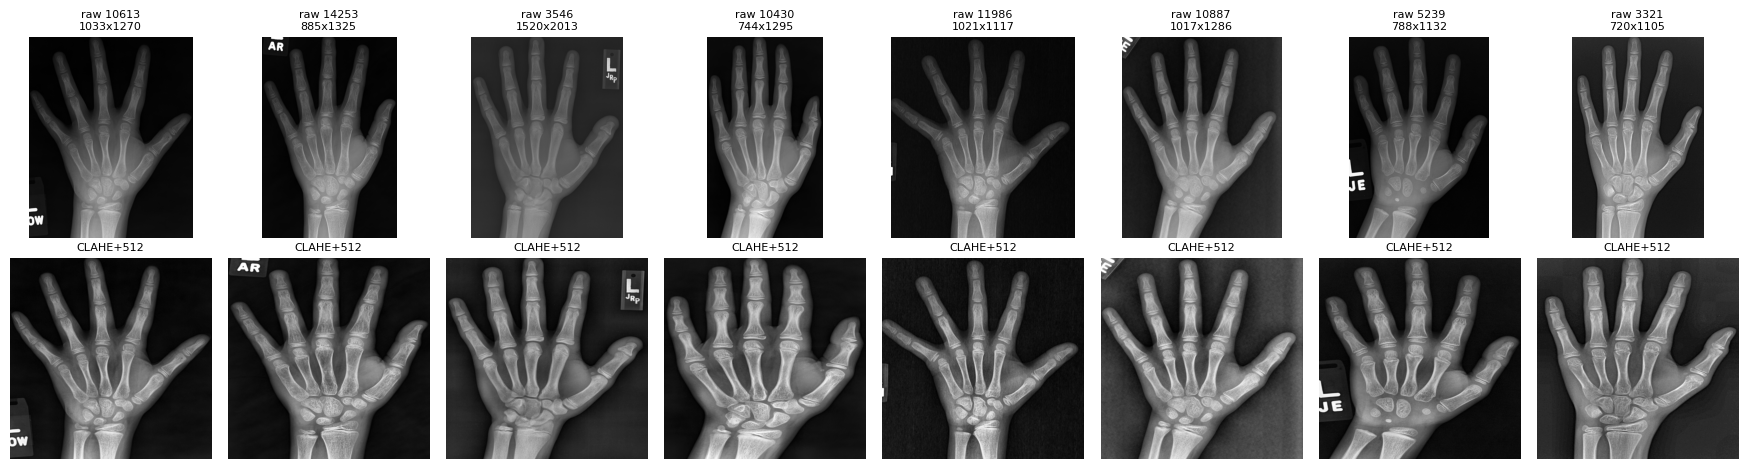

      id |   mean |    std |  dark<20
   10613 |   55.8 |   56.7 |   48.9%
   14253 |   67.3 |   58.1 |   31.3%
    3546 |   77.6 |   42.6 |    0.0%
   10430 |   72.1 |   58.4 |   35.7%
   11986 |   56.1 |   53.8 |   28.2%
   10887 |  102.3 |   47.7 |    0.0%
    5239 |   65.6 |   57.2 |   39.4%
    3321 |   61.1 |   13.0 |    0.0%


In [10]:
N_QC   = 8          # 확인할 장수 (16~24 권장)
QC_SEED = SEED

sample = train_df.sample(min(N_QC, len(train_df)), random_state=QC_SEED)
cols = min(8, len(sample)); rows = int(np.ceil(len(sample) / cols))
fig, axes = plt.subplots(rows*2, cols, figsize=(2.2*cols, 4.8*rows))
axes = np.atleast_2d(axes)
for j, (_, r) in enumerate(sample.iterrows()):
    rr, cc = (j // cols) * 2, j % cols
    raw = imread_kr(r["path"], cv2.IMREAD_GRAYSCALE)
    pre = imread_kr(CACHE_DIR/"train"/f"{r['id']}.png", cv2.IMREAD_GRAYSCALE)
    axes[rr,   cc].imshow(raw, cmap="gray")
    axes[rr,   cc].set_title(f"raw {r['id']}\n{raw.shape[1]}x{raw.shape[0]}", fontsize=8)
    axes[rr+1, cc].imshow(pre, cmap="gray")
    axes[rr+1, cc].set_title(f"CLAHE+{IMG_SIZE}", fontsize=8)
for ax in axes.ravel(): ax.axis("off")
plt.tight_layout(); plt.show()

# 밝기 분포 요약 — CLAHE 과증폭 여부를 수치로도 확인
stats = []
for _, r in sample.iterrows():
    pre = imread_kr(CACHE_DIR/"train"/f"{r['id']}.png", cv2.IMREAD_GRAYSCALE)
    stats.append((r["id"], float(pre.mean()), float(pre.std()), float((pre < 20).mean())))
print(f"{'id':>8} | {'mean':>6} | {'std':>6} | {'dark<20':>8}")
for i, m, s, d in stats:
    print(f"{i:>8} | {m:>6.1f} | {s:>6.1f} | {d:>7.1%}")

---
# PART 2 · 학습 설정 ⚙️  *(하이퍼파라미터를 여기서 바꾸고, 이 파트부터 아래로 재실행)*

In [11]:
# ── 하이퍼파라미터 (여기만 바꿔 재실험) ───────────────────────────────
BATCH_SIZE     = 16       # OOM 시 8
EPOCHS         = 100      # 넉넉히 — 조기종료가 알아서 멈춤
LR             = 1e-4
WEIGHT_DECAY   = 1e-5
FREEZE_BACKBONE= False    # 미세조정(False)=최고성능 / 동결(True)=빠름·안정
NUM_WORKERS    = 0        # Windows+Jupyter 안전값(.py에선 4+ 권장)
USE_AMP        = True
RESUME         = False    # last.pt에서 이어서 학습하려면 True
EARLY_STOP_PATIENCE = 15  # 검증 MAE가 이 에폭 수만큼 개선 없으면 조기종료(<0이면 끔)
MIN_DELTA           = 0.01# 개선으로 인정할 최소 MAE 감소(개월)

# ── 모델 구조 (논문 §3.4 · 미명시 항목은 주석으로 표시) ────────────────
GENDER_EMB_DIM = 32       # 논문 명시 (식 15, k=32)
HEAD_RELU      = True     # 논문 미명시 — Conv3x3 뒤 활성함수 (기본 ReLU)
GENDER_RELU    = True     # 논문 미명시 — 성별 Dense 뒤 활성함수 (기본 ReLU)
# ──────────────────────────────────────────────────────────────────
# 참고) 타깃은 학습셋 통계로 z-정규화 후 L1 학습(논문 미명시 · 수렴 안정화용 가정).
#       평가·저장·추론은 모두 개월 단위로 환산되므로 MAE 해석은 논문과 동일합니다.

ARCH = {"GENDER_EMB_DIM": GENDER_EMB_DIM, "HEAD_RELU": HEAD_RELU, "GENDER_RELU": GENDER_RELU,
        "BACKBONE": "xception", "IMG_SIZE": IMG_SIZE,
        "PREPROCESS": "clahe_only", "CROP_MODE": "none", "EQUALIZE": "clahe",
        "CLAHE_CLIP": CLAHE_CLIP, "CLAHE_TILE": CLAHE_TILE, "CLAHE_FIRST": CLAHE_FIRST,
        "RESIZE_MODE": RESIZE_MODE, "USE_AUG": USE_AUG, "USE_EXCLUDE_IDS": USE_EXCLUDE_IDS}
print("설정:", json.dumps(ARCH, ensure_ascii=False))
print(f"batch {BATCH_SIZE} | epochs {EPOCHS} | lr {LR} | resume {RESUME}")

설정: {"GENDER_EMB_DIM": 32, "HEAD_RELU": true, "GENDER_RELU": true, "BACKBONE": "xception", "IMG_SIZE": 512, "PREPROCESS": "clahe_only", "CROP_MODE": "none", "EQUALIZE": "clahe", "CLAHE_CLIP": 2.0, "CLAHE_TILE": 8, "CLAHE_FIRST": true, "RESIZE_MODE": "square", "USE_AUG": false, "USE_EXCLUDE_IDS": false}
batch 16 | epochs 100 | lr 0.0001 | resume False


In [12]:
# 데이터로더
train_loader = DataLoader(BoneAgeDataset(train_df, "train", train_tf),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(BoneAgeDataset(val_df, "val", eval_tf),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(BoneAgeDataset(test_df, "test", eval_tf),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True) if len(test_df) else None
print("배치 수: train", len(train_loader), "| val", len(val_loader),
      "| test", (len(test_loader) if test_loader else 0))

배치 수: train 788 | val 90 | test 13


In [13]:
# 모델·옵티마이저·스케줄러 (RESUME이면 last.pt에서 복원)
model     = build_model(ARCH, pretrained=True, freeze=FREEZE_BACKBONE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, "min", factor=0.5, patience=3)
scaler    = torch.amp.GradScaler("cuda", enabled=USE_AMP and torch.cuda.is_available())

if RESUME and LAST_CKPT.exists():
    ck = torch_load(LAST_CKPT, map_location=device)
    # 체크포인트 호환성 검사 — 구조가 다르면 조용히 망가지는 대신 즉시 알림
    bad = [k for k in ("IMG_SIZE","GENDER_EMB_DIM") if ck["arch"].get(k) != ARCH.get(k)]
    assert not bad, f"체크포인트 구조 불일치: {bad} — RESUME=False로 새로 학습하세요."
    model.load_state_dict(ck["model"]); optimizer.load_state_dict(ck["optimizer"])
    scheduler.load_state_dict(ck["scheduler"]); scaler.load_state_dict(ck["scaler"])
    start_epoch = ck["epoch"] + 1; best_val = ck["best_val"]; history = ck["history"]
    epochs_no_improve = ck.get("no_improve", 0)
    print(f"🔄 재개: epoch {start_epoch}부터 · best_val {best_val:.2f} · 개선정체 {epochs_no_improve}")
else:
    start_epoch, best_val, epochs_no_improve = 1, float("inf"), 0
    history = {"train_mae": [], "val_mae": []}
    print("🆕 새로 학습 시작")

n_params = sum(p.numel() for p in model.parameters())/1e6
print(f"파라미터 {n_params:.1f}M (논문 표4 ≈22.9M)")

[backbone] timm 'legacy_xception' 로드 완료 (pretrained=True)
[model] backbone out = 2048x16x16  ->  z dim = 6,400   (논문 9,216 = IMG_SIZE 608일 때)
[model] total params = 25.5M   (논문 표4: 22.9M)
🆕 새로 학습 시작
파라미터 25.5M (논문 표4 ≈22.9M)


---
# PART 3 · 학습  *(best 즉시 저장 · 조기 종료 · 중단 재개)*
- `best.pt`: 검증 MAE 최저 순간 저장 → PART 4가 이걸 로드
- `last.pt`: 매 에폭 저장(조기종료 카운터 포함) → `RESUME=True`로 재개
- Kernel 정지 버튼을 눌러도 `KeyboardInterrupt`를 잡아 `last.pt`를 남깁니다.

**기대치**: 크롭 없는 베이스라인이므로 크롭 버전(≈5.1개월)보다 **나쁘게 나오는 것이 정상**입니다. 그 차이가 곧 전처리의 기여분입니다.

In [14]:
criterion = nn.L1Loss()
AMP_ON = USE_AMP and torch.cuda.is_available()
best_epoch = start_epoch - epochs_no_improve   # best가 나온 에폭(로그용)
try:
    for epoch in range(start_epoch, EPOCHS + 1):
        model.train(); run_abs, seen = 0.0, 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch:02d}/{EPOCHS}")
        for x, g, yn, ym in pbar:
            x, g, yn = x.to(device), g.to(device), yn.to(device).squeeze(1)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=AMP_ON):
                pred = model(x, g); loss = criterion(pred, yn)
            scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
            run_abs += mae_months(pred, ym, AGE_MEAN, AGE_STD); seen += x.size(0)
            pbar.set_postfix(train_mae=f"{run_abs/seen:.2f}")

        tr_mae = run_abs / seen
        va_mae = evaluate(model, val_loader, AGE_MEAN, AGE_STD, AMP_ON)
        scheduler.step(va_mae)
        history["train_mae"].append(tr_mae); history["val_mae"].append(va_mae)

        # 개선 판정(MIN_DELTA 이상 감소해야 개선으로 인정)
        if va_mae < best_val - MIN_DELTA:
            best_val = va_mae; epochs_no_improve = 0; best_epoch = epoch
            save_checkpoint(BEST_CKPT, model, ARCH, AGE_MEAN, AGE_STD, best_val=best_val)
            flag = f"✔ best 저장 (val {best_val:.2f})"
        else:
            epochs_no_improve += 1
            flag = f"개선 없음 {epochs_no_improve}/{EARLY_STOP_PATIENCE}"
        print(f"  → train {tr_mae:.2f} · val {va_mae:.2f} · lr {optimizer.param_groups[0]['lr']:.1e} · {flag}")

        # 매 에폭 last 저장(조기종료 카운터 포함) + history 저장
        save_checkpoint(LAST_CKPT, model, ARCH, AGE_MEAN, AGE_STD,
                        optimizer, scheduler, scaler, epoch, best_val, history,
                        no_improve=epochs_no_improve)
        json.dump(history, open(HISTORY_JSON, "w"))

        # 조기 종료 (EARLY_STOP_PATIENCE < 0 이면 비활성)
        if EARLY_STOP_PATIENCE >= 0 and epochs_no_improve >= EARLY_STOP_PATIENCE:
            print(f"\n⏹ 조기 종료: {EARLY_STOP_PATIENCE}에폭 연속 개선 없음 "
                  f"· 최고 MAE {best_val:.2f} @ epoch {best_epoch}")
            break
    else:
        print(f"\n🏁 정상 종료(전체 {EPOCHS}에폭) · 최고 검증 MAE {best_val:.2f} @ epoch {best_epoch}")
except KeyboardInterrupt:
    save_checkpoint(LAST_CKPT, model, ARCH, AGE_MEAN, AGE_STD,
                    optimizer, scheduler, scaler, epoch, best_val, history,
                    no_improve=epochs_no_improve)
    json.dump(history, open(HISTORY_JSON, "w"))
    print(f"\n⏸ 중단 감지 — last.pt 저장(epoch {epoch}). PART 2에서 RESUME=True로 재개하세요.")

Epoch 01/100:   0%|          | 0/788 [00:00<?, ?it/s]

  → train 12.23 · val 8.87 · lr 1.0e-04 · ✔ best 저장 (val 8.87)


Epoch 02/100:   0%|          | 0/788 [00:00<?, ?it/s]

  → train 8.28 · val 8.25 · lr 1.0e-04 · ✔ best 저장 (val 8.25)


Epoch 03/100:   0%|          | 0/788 [00:00<?, ?it/s]

...

  → train 3.58 · val 7.85 · lr 1.0e-04 · 개선 없음 2/15


Epoch 12/100:   0%|          | 0/788 [00:00<?, ?it/s]

  → train 3.51 · val 7.34 · lr 1.0e-04 · 개선 없음 3/15


Epoch 13/100:   0%|          | 0/788 [00:00<?, ?it/s]

AcceleratorError: CUDA error: unknown error
Search for `cudaErrorUnknown' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


---
# PART 4 · 평가·설명·추론  *(학습 없이 저장된 best.pt만 로드 — 다른 사람도 이 파트만 실행 가능)*
> 이 셀을 먼저 실행하면 `eval_model`이 준비됩니다. 단일 이미지 추론(맨 아래)은 `best.pt` + 이미지 1장이면 됩니다.

In [ ]:
assert BEST_CKPT.exists(), "best.pt 없음 — PART 3을 먼저 실행하거나 체크포인트를 받아 checkpoints 폴더에 두세요."
ck = torch_load(BEST_CKPT, map_location=device)
eval_model = build_model(ck["arch"], pretrained=False)
eval_model.load_state_dict(ck["model"]); eval_model.eval()
EM_MEAN, EM_STD, EM_IMG = ck["age_mean"], ck["age_std"], ck["arch"]["IMG_SIZE"]
print(f"✅ best.pt 로드 완료 · 정규화 {EM_MEAN:.1f}±{EM_STD:.1f} · IMG {EM_IMG}")
print(f"   전처리 = {ck['arch'].get('PREPROCESS')} · best val MAE {ck.get('best_val', float('nan')):.2f}")

### 4-1. 학습 곡선 (history.json 로드)

In [ ]:
hist = json.load(open(HISTORY_JSON)) if HISTORY_JSON.exists() else history
ep = range(1, len(hist["train_mae"]) + 1)
plt.figure(figsize=(8, 5))
plt.plot(ep, hist["train_mae"], "-o", ms=3, label="train MAE")
plt.plot(ep, hist["val_mae"],   "-o", ms=3, label="val MAE")
plt.axhline(4.10, ls="--", c="green", label="paper 4.10 (InceptionV3+Bilinear)")
plt.axhline(5.12, ls=":",  c="orange", label="paper 5.12 (Xception, no preproc)")
plt.xlabel("Epoch"); plt.ylabel("MAE (months)")
plt.title("Validation MAE vs Epoch — CLAHE only (no crop)")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()
print(f"최저 검증 MAE = {min(hist['val_mae']):.2f} @ epoch {int(np.argmin(hist['val_mae']))+1}")

### 4-2. 검증셋 예측 · 산점도 · 연령대별 MAE

In [ ]:
# PART 2를 안 돌렸어도 독립 실행되도록 val_loader를 여기서 구성
_val_loader = DataLoader(BoneAgeDataset(val_df, "val", eval_tf),
    batch_size=16, shuffle=False, num_workers=0, pin_memory=True)

preds, trues = [], []
with torch.no_grad():
    for x, g, yn, ym in tqdm(_val_loader, desc="predict"):
        x, g = x.to(device), g.to(device)
        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            p = eval_model(x, g)
        preds.append(p.cpu()*EM_STD + EM_MEAN); trues.append(ym.squeeze(1))
preds = torch.cat(preds).numpy(); trues = torch.cat(trues).numpy()

overall  = np.abs(preds - trues).mean()
val_rmse = np.sqrt(np.mean((preds - trues)**2))
print(f"전체 검증 MAE {overall:.2f} · RMSE {val_rmse:.2f} 개월 · 편향 {np.mean(preds-trues):+.2f}")

plt.figure(figsize=(6, 6)); plt.scatter(trues, preds, s=8, alpha=.4)
lim = [0, max(trues.max(), preds.max())+5]; plt.plot(lim, lim, "r--")
plt.xlabel("True (months)"); plt.ylabel("Pred (months)")
plt.title(f"Validation · MAE={overall:.2f} · RMSE={val_rmse:.2f}mo"); plt.tight_layout(); plt.show()

bins, labels = [0,48,96,144,192,10**5], ["0-4y","4-8y","8-12y","12-16y",">16y"]
print(f"{'group':>7} | {'N':>4} | {'MAE':>5} | {'bias':>6}")
for lo, hi, lab in zip(bins[:-1], bins[1:], labels):
    m = (trues>=lo) & (trues<hi)
    if m.sum(): print(f"{lab:>7} | {m.sum():>4} | {np.abs(preds[m]-trues[m]).mean():>5.2f} | {np.mean(preds[m]-trues[m]):>+6.2f}")

### 4-3. 최종 테스트셋 평가 — MAE / RMSE
학습에 전혀 쓰지 않은 **test 세트**로 최종 성능을 측정합니다.
`USE_EXCLUDE_IDS=False`이므로 **필터링 없는 정직한 수치**입니다 — 이전 노트북(필터 적용)과 비교할 때 이 차이를 반드시 명시하세요.

In [ ]:
assert test_loader is not None and len(test_df), \
    "test 세트가 없습니다 — 셀 0-3의 TEST_IMG_DIR / TEST_CSV 경로를 확인하고 PART 1을 다시 실행하세요."

t_preds, t_trues = [], []
with torch.no_grad():
    for x, g, yn, ym in tqdm(test_loader, desc="test"):
        x, g = x.to(device), g.to(device)
        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            p = eval_model(x, g)
        t_preds.append(p.cpu()*EM_STD + EM_MEAN); t_trues.append(ym.squeeze(1))
t_preds = torch.cat(t_preds).numpy(); t_trues = torch.cat(t_trues).numpy()

test_mae  = np.abs(t_preds - t_trues).mean()
test_rmse = np.sqrt(np.mean((t_preds - t_trues)**2))
test_bias = float(np.mean(t_preds - t_trues))
print("="*52)
print(f"  전처리     = CLAHE only (crop 없음) · {IMG_SIZE}px")
print(f"  TEST  MAE  = {test_mae:5.2f} 개월")
print(f"  TEST  RMSE = {test_rmse:5.2f} 개월")
print(f"  TEST  bias = {test_bias:+5.2f} 개월   (N={len(t_trues)})")
print("="*52)

plt.figure(figsize=(6, 6)); plt.scatter(t_trues, t_preds, s=8, alpha=.4)
lim = [0, max(t_trues.max(), t_preds.max())+5]; plt.plot(lim, lim, "r--")
plt.xlabel("True (months)"); plt.ylabel("Pred (months)")
plt.title(f"Test · MAE={test_mae:.2f} · RMSE={test_rmse:.2f} mo")
plt.tight_layout(); plt.show()

bins, labels = [0,48,96,144,192,10**5], ["0-4y","4-8y","8-12y","12-16y",">16y"]
print(f"{'group':>7} | {'N':>4} | {'MAE':>5} | {'RMSE':>5} | {'bias':>6}")
for lo, hi, lab in zip(bins[:-1], bins[1:], labels):
    m = (t_trues>=lo) & (t_trues<hi)
    if m.sum():
        mae_g  = np.abs(t_preds[m]-t_trues[m]).mean()
        rmse_g = np.sqrt(np.mean((t_preds[m]-t_trues[m])**2))
        print(f"{lab:>7} | {m.sum():>4} | {mae_g:>5.2f} | {rmse_g:>5.2f} | {np.mean(t_preds[m]-t_trues[m]):>+6.2f}")

# 결과를 JSON으로 남겨 다른 전처리 설정과 표로 비교하기 쉽게
res = {"preprocess": "clahe_only", "img_size": IMG_SIZE, "clahe_clip": CLAHE_CLIP,
       "clahe_tile": CLAHE_TILE, "resize_mode": RESIZE_MODE,
       "use_exclude_ids": USE_EXCLUDE_IDS,
       "val_best_mae": float(ck.get("best_val", float("nan"))),
       "test_mae": float(test_mae), "test_rmse": float(test_rmse),
       "test_bias": test_bias, "n_test": int(len(t_trues))}
json.dump(res, open(CKPT_DIR/"result_summary.json", "w", encoding="utf-8"),
          ensure_ascii=False, indent=2)
print("\n결과 요약 저장:", CKPT_DIR/"result_summary.json")

### 4-4. Grad-CAM — **전처리 없음이 왜 불리한지 눈으로 확인**
크롭을 하지 않았으므로, 모델의 관심이 손가락·손목 성장판이 아니라 **프레임·문자마커·여백**으로 새는지 확인할 수 있습니다.
여기서 엉뚱한 곳이 밝다면 그것이 곧 크롭 전처리를 정당화하는 증거입니다.

In [ ]:
def _pick_cam_layer(backbone):
    '''Xception 백본에서 Grad-CAM 대상 레이어를 자동 선택 (없으면 백본 전체).'''
    mods = dict(backbone.named_modules())
    for name in ("act4", "bn4", "conv4", "block12"):
        if name in mods:
            return mods[name], name
    return backbone, "backbone(output)"

class GradCAM:
    '''백본 마지막 특징맵 기준 Grad-CAM (회귀 출력).'''
    def __init__(self, model):
        self.model = model; self.feat = self.grad = None
        tgt, name = _pick_cam_layer(model.backbone)
        print(f"[Grad-CAM] target layer = {name}")
        tgt.register_forward_hook(lambda m,i,o: setattr(self, "feat", o.detach()))
        tgt.register_full_backward_hook(lambda m,gi,go: setattr(self, "grad", go[0].detach()))
    def __call__(self, x, g):
        self.model.eval(); out = self.model(x, g); self.model.zero_grad(); out.sum().backward()
        w = self.grad.mean(dim=(2,3), keepdim=True)
        cam = F.relu((w*self.feat).sum(1))[0]
        cam = (cam-cam.min())/(cam.max()-cam.min()+1e-8)
        return cam.cpu().numpy(), out.item()

cam_engine = GradCAM(eval_model)
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
for ax, (_, r) in zip(axes, val_df.sample(4, random_state=1).iterrows()):
    g = imread_kr(CACHE_DIR/"val"/f"{r['id']}.png", cv2.IMREAD_GRAYSCALE)
    x = eval_tf(np.stack([g]*3, -1)).unsqueeze(0).to(device)
    gd = torch.tensor([[r["male"]]], dtype=torch.float32, device=device)
    cam, pn = cam_engine(x, gd); pred_month = pn*EM_STD + EM_MEAN
    heat = cv2.applyColorMap(np.uint8(255*cv2.resize(cam,(EM_IMG,EM_IMG))), cv2.COLORMAP_JET)
    over = cv2.addWeighted(cv2.cvtColor(g, cv2.COLOR_GRAY2BGR), 0.55, heat, 0.45, 0)
    ax.imshow(cv2.cvtColor(over, cv2.COLOR_BGR2RGB))
    ax.set_title(f"pred {pred_month:.0f}/true {int(r.boneage)}mo"); ax.axis("off")
plt.tight_layout(); plt.show()

### 4-5. 단일 이미지 추론 (완전 독립 — best.pt + 이미지 1장이면 끝)
전처리 상수(CLAHE 파라미터·리사이즈 방식)를 **체크포인트에서 읽어** 학습 때와 동일한 처리를 보장합니다.

In [ ]:
def predict_bone_age(image_path, is_male, ckpt_path=BEST_CKPT):
    '''원본 X-ray 경로 + 성별(True=남) -> 골연령(개월). 전처리·정규화상수 모두 체크포인트에서.'''
    ck = torch_load(ckpt_path, map_location=device)
    a  = ck["arch"]
    m  = build_model(a, pretrained=False); m.load_state_dict(ck["model"]); m.eval()
    g = imread_kr(image_path, cv2.IMREAD_GRAYSCALE)
    if g is None: raise FileNotFoundError(image_path)
    pre = preprocess(g,
                     size        = a["IMG_SIZE"],
                     clip        = a.get("CLAHE_CLIP", 2.0),
                     tile        = a.get("CLAHE_TILE", 8),
                     mode        = a.get("RESIZE_MODE", "square"),
                     clahe_first = a.get("CLAHE_FIRST", True))
    x  = eval_tf(np.stack([pre]*3, -1)).unsqueeze(0).to(device)
    gd = torch.tensor([[float(is_male)]], dtype=torch.float32, device=device)
    with torch.no_grad(), torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
        pn = m(x, gd).item()
    return pn * ck["age_std"] + ck["age_mean"]

# 예시:
# months = predict_bone_age(VAL_IMG_DIR / "1386.png", is_male=True)
# print(f"예측 골연령: {months:.1f} 개월 ({months/12:.1f}세)")
print("추론 함수 준비 완료 · best.pt:", BEST_CKPT)